# Import Packages

In [1]:
# built-in
from ast import literal_eval
import itertools
import os.path

# third-party (pip install required)
import matplotlib
from matplotlib.colors import to_rgba_array
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import pylab
from pymodulon.io import load_json_model, save_to_json
from pymodulon.plotting import plot_expression
from scipy.stats import mannwhitneyu, median_abs_deviation, pearsonr, skew
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

# set matplotlib params
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.color'] = 'black'
matplotlib.rcParams['axes.labelcolor'] = 'black'
matplotlib.rcParams['xtick.color'] = 'black'
matplotlib.rcParams['ytick.color'] = 'black'
matplotlib.rcParams['font.sans-serif'] = "Arial"
matplotlib.rcParams['font.family'] = "sans-serif"

# Load Data

In [2]:
pmg = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')
pmg_sample_table = pmg.sample_table
log_tpm = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\log_tpm.csv', index_col=0)

In [3]:
# drop duplicate samples - CFP project
log_tpm = log_tpm.drop(pmg_sample_table.loc[pmg_sample_table.project == 'CFP'].qc_id.values, axis = 1)

In [4]:
y_ome_annot = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\annotation\\additional_gene_annotations\\y_ome_annotations\\y_ome_categories.csv')
y_ome_annot.head()

,Object ID,Accession-1,Gene Name,Product,Characterization,log_TPM_median,range,in_iM,precise mapping issue
0,G0-17105,b4830,aceK-int,small RNA AceK-int,PARTIAL,NaN,NaN,NaN,1
1,G0-9281,NaN,alaB,glutamate&mdash;pyruvate aminotransferase AlaB,PARTIAL,NaN,NaN,NaN,1
2,G0-17106,b4831,allZ,small RNA AllZ,PARTIAL,NaN,NaN,NaN,1
3,EG12112,b2624,alpA,CP4-57 prophage; DNA-binding transcriptional a...,PARTIAL,NaN,NaN,NaN,1
4,G0-17125,b4844,ameF,small antisense RNA aMEF,PARTIAL,NaN,NaN,NaN,1


In [5]:
y_ome_annot.dropna(subset=['Accession-1'], inplace=True)

In [6]:
y_ome_annot = y_ome_annot.set_index('Accession-1')

In [7]:
y_ome_annot.loc[list(set(pmg.gene_table.index.values).intersection(set(y_ome_annot.index.values)))].Characterization.value_counts()

WELL-CHARACTERIZED    2389
PARTIAL               1180
UNCHARACTERIZED        719
Pseudo-Genes            17
Name: Characterization, dtype: int64

In [8]:
# adding y_ome annotations
pmg.gene_table['y_ome'] = False
pmg.gene_table.y_ome.value_counts()

False    4305
Name: y_ome, dtype: int64

In [9]:
for gene in list(set(pmg.gene_table.index.values).intersection(set(y_ome_annot.index.values))):
    if y_ome_annot.loc[gene, 'Characterization'] == 'PARTIAL':
        pmg.gene_table.loc[gene, 'y_ome'] = True
    if y_ome_annot.loc[gene, 'Characterization'] == 'UNCHARACTERIZED':
        pmg.gene_table.loc[gene, 'y_ome'] = True

In [10]:
pmg.gene_table.y_ome.value_counts()

False    2406
True     1899
Name: y_ome, dtype: int64

In [11]:
pmg.gene_table.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM,y_ome
b0001,thrL,U00096.3,NaN,190,255,+,thr operon leader peptide,No COG annotation,P0AD86,Op0,"Lrp,RpoD,ppGpp,DksA",True,True
b0002,thrA,U00096.3,NaN,337,2799,+,fused aspartate kinase/homoserine dehydrogenase 1,Amino acid transport and metabolism,P00561,Op1,"ArcA,RpoD,Fnr,ppGpp,DksA,Ile-tRNA,Thr-tRNA",True,False
b0003,thrB,U00096.3,NaN,2801,3733,+,homoserine kinase,Nucleotide transport and metabolism,P00547,Op2,"RpoD,ppGpp,DksA,Ile-tRNA,Thr-tRNA",True,False
b0004,thrC,U00096.3,NaN,3734,5020,+,threonine synthase,Amino acid transport and metabolism,P00934,Op3,"ppGpp,RpoD,DksA,Ile-tRNA,Thr-tRNA",True,False
b0005,yaaX,U00096.3,NaN,5234,5530,+,DUF2502 domain-containing protein YaaX,Function unknown,P75616,Op4,Lrp,True,True


# Gene Expression Breakdowns

## Load Gene Table

In [12]:
gene_table = pmg.gene_table
gene_table.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator,in_iM,y_ome
b0001,thrL,U00096.3,NaN,190,255,+,thr operon leader peptide,No COG annotation,P0AD86,Op0,"Lrp,RpoD,ppGpp,DksA",True,True
b0002,thrA,U00096.3,NaN,337,2799,+,fused aspartate kinase/homoserine dehydrogenase 1,Amino acid transport and metabolism,P00561,Op1,"ArcA,RpoD,Fnr,ppGpp,DksA,Ile-tRNA,Thr-tRNA",True,False
b0003,thrB,U00096.3,NaN,2801,3733,+,homoserine kinase,Nucleotide transport and metabolism,P00547,Op2,"RpoD,ppGpp,DksA,Ile-tRNA,Thr-tRNA",True,False
b0004,thrC,U00096.3,NaN,3734,5020,+,threonine synthase,Amino acid transport and metabolism,P00934,Op3,"ppGpp,RpoD,DksA,Ile-tRNA,Thr-tRNA",True,False
b0005,yaaX,U00096.3,NaN,5234,5530,+,DUF2502 domain-containing protein YaaX,Function unknown,P75616,Op4,Lrp,True,True


### Add in_iM Column

Only to be run once

In [13]:
# genes_in_im = []
# for im in pmg.imodulon_names:
#     genes_in_im.extend(list(pmg.view_imodulon(im).index))
# genes_in_im = list(set(genes_in_im))

# gene_table = gene_table.assign(
#     in_iM=gene_table.apply(lambda row: row.name in genes_in_im, axis=1)
# )

In [14]:
# gene_table.to_csv('C:\\Users\\99hee\\precise_mg1655\\data\\annotation\\gene_info_updated.csv')

In [15]:
# pmg.gene_table = gene_table

In [16]:
# save_to_json(pmg, 'C:\\Users\\99hee\\precise_mg1655\\data\\p_mg1655\\updated\\PRECISE_WT_MG1655_final1.json.gz', compress=True)

In [17]:
count = 0
for idx, row in pmg.gene_table.iterrows():
    if len(pmg.imodulons_with(idx)) > 0:
        count += 1
count

1385

In [18]:
# double check in_iM column
pmg.gene_table['in_iM'].value_counts()

False    2920
True     1385
Name: in_iM, dtype: int64

### Select Non-Manipulated Genes/Samples

Exclude explicit genetic modifications such as gene KOs and ALE conditions to allow exploration of "natural" variation

NOTE: for P-MG1655, all samples are non-manipulated

In [21]:
# select only genes in PMG
# gene_table_pmg = gene_table
gene_table_pmg = pmg.gene_table
# create a copy of the log_tpm table that has entries removed for genes that are explicitly KO'ed
# also want to ignore all ALEs for these purposes to avoid deletion effects
log_tpm_no_ko = log_tpm.copy()

# add some columns to gene table just for these plots (won't re-save table)
gene_table_pmg = gene_table_pmg.assign(
    median_log_tpm=log_tpm_no_ko.median(axis=1),
    # this function doesn't nicely drop NAs automatically like the native DataFrame methods
    mad_log_tpm=log_tpm_no_ko.apply(lambda row: median_abs_deviation(row.dropna()), axis=1),
    max_log_tpm=log_tpm_no_ko.max(axis=1),
    min_log_tpm=log_tpm_no_ko.min(axis=1),
    mean_log_tpm=log_tpm_no_ko.mean(axis=1),
    skew=log_tpm_no_ko.skew(axis=1)
)
gene_table_pmg = gene_table_pmg.assign(
    range_log_tpm=(gene_table_pmg['max_log_tpm'] - gene_table_pmg['min_log_tpm']),
    max_to_median=(gene_table_pmg['max_log_tpm'] - gene_table_pmg['median_log_tpm']),
    min_to_median=(gene_table_pmg['min_log_tpm'] - gene_table_pmg['median_log_tpm'])
)

gene_table_pmg.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b0001,thrL,U00096.3,NaN,190,255,+,thr operon leader peptide,No COG annotation,P0AD86,Op0,...,True,11.336382,2.299772,16.603621,0.000000,10.993618,-0.485891,16.603621,5.267239,-11.336382
b0002,thrA,U00096.3,NaN,337,2799,+,fused aspartate kinase/homoserine dehydrogenase 1,Amino acid transport and metabolism,P00561,Op1,...,False,9.982203,0.553437,11.841509,3.882181,9.198095,-1.274968,7.959327,1.859306,-6.100021
b0003,thrB,U00096.3,NaN,2801,3733,+,homoserine kinase,Nucleotide transport and metabolism,P00547,Op2,...,False,9.678968,0.523981,11.464290,4.490016,9.020447,-1.168499,6.974274,1.785322,-5.188952
b0004,thrC,U00096.3,NaN,3734,5020,+,threonine synthase,Amino acid transport and metabolism,P00934,Op3,...,False,9.660446,0.463761,11.072894,4.331133,8.951168,-1.204108,6.741761,1.412448,-5.329313
b0005,yaaX,U00096.3,NaN,5234,5530,+,DUF2502 domain-containing protein YaaX,Function unknown,P75616,Op4,...,True,6.085451,0.538300,11.269566,1.743077,5.898876,0.038363,9.526489,5.184115,-4.342374


## Statistical Comparisons

Running Mann-Whitney U tests for the medians of categories plotted below

In [22]:
cols = ['in_iM', 'y_ome']

stats_df = pd.DataFrame(columns=['n_yes', 'n_no', 'U', 'P', 'U_mad', 'P_mad'])

for col in cols:
    if col == 'y_ome':
        yes_log_tpm_meds = gene_table_pmg[gene_table_pmg[col]]['median_log_tpm'].values
        no_log_tpm_meds = gene_table_pmg[~gene_table_pmg[col]]['median_log_tpm'].values
        n_yes = len(yes_log_tpm_meds)
        n_no = len(no_log_tpm_meds)
        U, p = mannwhitneyu(yes_log_tpm_meds, no_log_tpm_meds)
        yes_log_tpm_mads = gene_table_pmg[gene_table_pmg[col]]['mad_log_tpm'].values
        no_log_tpm_mads = gene_table_pmg[~gene_table_pmg[col]]['mad_log_tpm'].values
        U_mad, p_mad = mannwhitneyu(yes_log_tpm_mads, no_log_tpm_mads)
        stats_df.loc[col] = [n_yes, n_no, U, p, U_mad, p_mad]
    if col == 'in_iM':
        yes_log_tpm_meds = gene_table_pmg[gene_table_pmg[col] == 'True']['median_log_tpm'].values
        no_log_tpm_meds = gene_table_pmg[gene_table_pmg[col] == 'False']['median_log_tpm'].values
        n_yes = len(yes_log_tpm_meds)
        n_no = len(no_log_tpm_meds)
        U, p = mannwhitneyu(yes_log_tpm_meds, no_log_tpm_meds)
        yes_log_tpm_mads = gene_table_pmg[gene_table_pmg[col] == 'True']['mad_log_tpm'].values
        no_log_tpm_mads = gene_table_pmg[gene_table_pmg[col] == 'False']['mad_log_tpm'].values
        U_mad, p_mad = mannwhitneyu(yes_log_tpm_mads, no_log_tpm_mads)
        stats_df.loc[col] = [n_yes, n_no, U, p, U_mad, p_mad]
    
stats_df

,n_yes,n_no,U,P,U_mad,P_mad
in_iM,1385.0,2920.0,2081528.5,1.187556e-01,3348438.5,1.340165e-265
y_ome,1899.0,2406.0,1478016.5,2.861025e-88,2473919.5,2.894628e-06


## Helper Functions

In [23]:
def plot_expression_stat_2d_hist(statx, staty, labelx, labely, xlim, ylim, x_ticks, y_ticks, fname, return_g=False):

    g = sns.JointGrid(data=gene_table_pmg, x=statx,y=staty,
                      xlim=xlim, ylim=ylim,
                      height=4, marginal_ticks=False)
    g.plot_joint(sns.histplot, color='slategray', bins=25)
    g.plot_marginals(sns.boxplot, color='slategray', fliersize=0.5, linewidth=0.5)

    g.ax_joint.set_xlabel(labelx, fontsize=7)
    g.ax_joint.set_ylabel(labely, fontsize=7)
    g.ax_joint.set_xticks(x_ticks)
    g.ax_joint.set_yticks(y_ticks)
    for s in g.ax_joint.spines.values():
        s.set_visible(True)
        s.set_color('k')
        s.set_linewidth(0.9)

    for s in (list(g.ax_marg_x.spines.values()) + list(g.ax_marg_y.spines.values())):
        s.set_visible(False)
        
    if return_g:
        return g
        
#     plt.savefig(os.path.join(FIG_PATH, f'{fname}.png'), bbox_inches='tight', dpi=400)
#     plt.savefig(os.path.join(FIG_PATH, f'{fname}.svg'), bbox_inches='tight', dpi=400)

In [24]:
sns.set_style('whitegrid')

def plot_jointgrid(genes, color, title, filename):
    g = sns.JointGrid(data=gene_table_pmg.loc[genes], x='median_log_tpm',y='mad_log_tpm',
                      xlim=(0, 15), ylim=(0, 3),
                      height=1.75, marginal_ticks=False)
    g.plot_joint(sns.histplot, color=color, bins=25)
    g.plot_marginals(sns.boxplot, color=color, fliersize=0.5, linewidth=0.5)

    g.ax_joint.set_xlabel('Median $log_{2}$[TPM]', fontsize=9)
    g.ax_joint.set_ylabel('MAD $log_{2}$[TPM]', fontsize=9)
    g.ax_joint.set_xticks(np.arange(0, 20, 5))
    for s in g.ax_joint.spines.values():
        s.set_visible(True)
        s.set_color('k')
        s.set_linewidth(0.9)
        
    g.ax_marg_x.set_title(f'{title} (n={len(genes)})', fontsize=10)

    for s in (list(g.ax_marg_x.spines.values()) + list(g.ax_marg_y.spines.values())):
        s.set_visible(False)
        
#     plt.savefig(os.path.join(FIG_PATH, f'{filename}.png'), bbox_inches='tight', dpi=400)
#     plt.savefig(os.path.join(FIG_PATH, f'{filename}.svg'), bbox_inches='tight', dpi=400)

def plot_expression_by_boolean_category(bool_col, filename_prefix, title_base, title_negate='not'):
    
    # get the yes/no genes from the category column
    if bool_col == 'y_ome':
        yes_genes = gene_table_pmg[gene_table_pmg[bool_col]].index
        no_genes = gene_table_pmg[~gene_table_pmg[bool_col]].index
    if bool_col == 'in_iM':
        yes_genes = gene_table_pmg[gene_table_pmg[bool_col] == 'True'].index
        no_genes = gene_table_pmg[gene_table_pmg[bool_col] == 'False'].index
    
    plot_jointgrid(yes_genes, 'tab:blue', title_base, f'{filename_prefix}_yes')
    plot_jointgrid(no_genes, 'tab:red', f'{title_negate} {title_base}', f'{filename_prefix}_no')

## Median and MAD

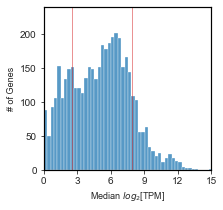

In [25]:
sns.set_style('ticks')

_, ax = plt.subplots(figsize=(3, 3))

sns.histplot(gene_table_pmg['median_log_tpm'], bins=50, ax=ax)

ax.set_xlabel('Median $log_{2}$[TPM]', fontsize=9)
ax.set_ylabel('# of Genes', fontsize=9)

ax.set_xlim(0, 15)
ax.set_ylim(0, 240)

ax.set_xticks(np.arange(0, 18, 3))

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('k')
    s.set_linewidth(1.2)

tpm_med, tpm_sd = gene_table_pmg['median_log_tpm'].median(), gene_table_pmg['median_log_tpm'].std()
borders = tpm_med - tpm_sd, tpm_med + tpm_sd
for border in borders:
    ax.axvline(border, color='tab:red', linewidth=0.5)

# plt.savefig(os.path.join(FIG_PATH, 'median_tpm_categories.png'), bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, 'median_tpm_categories.svg'), bbox_inches='tight', dpi=400)

### MAD Categories

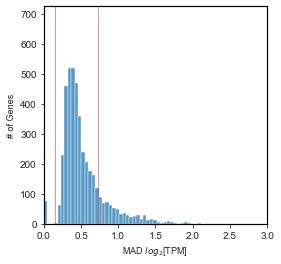

In [26]:
_, ax = plt.subplots(figsize=(4, 4))

sns.histplot(gene_table_pmg['mad_log_tpm'], bins=50, ax=ax)

ax.set_xlabel('MAD $log_{2}$[TPM]', fontsize=9)
ax.set_ylabel('# of Genes', fontsize=9)

ax.set_xlim(0, 3)
ax.set_ylim(0, 725)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('k')
    s.set_linewidth(1.2)

mad_med, mad_sd = gene_table_pmg['mad_log_tpm'].median(), gene_table_pmg['mad_log_tpm'].std()
borders = mad_med - mad_sd, mad_med + mad_sd
for border in borders:
    ax.axvline(border, color='tab:red', linewidth=0.5)

# plt.savefig(os.path.join(FIG_PATH, 'mad_tpm_categories.png'), bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, 'mad_tpm_categories.svg'), bbox_inches='tight', dpi=400)

### Median Expression and Median Absolute Deviation

In [27]:
# high m exp, medium mad
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 5:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 1.6:
            print(gene_table_pmg.loc[gene])
            print('---------------')

gene_name                      yadX
accession                  U00096.3
old_locus_tag                   NaN
start                        175048
end                          175095
strand                            +
gene_product           protein YadX
COG               No COG annotation
uniprot                      P0DSE3
operon                        Op154
regulator                       NaN
in_iM                          True
y_ome                          True
median_log_tpm             1.868127
mad_log_tpm                1.868127
max_log_tpm                 7.11022
min_log_tpm                     0.0
mean_log_tpm               1.910054
skew                       0.414402
range_log_tpm               7.11022
max_to_median              5.242093
min_to_median             -1.868127
Name: b4765, dtype: object
---------------
gene_name                                           csgC
accession                                       U00096.3
old_locus_tag                                      

In [28]:
gene_table_pmg.loc[gene_table_pmg.gene_name == 'grcA'][['median_log_tpm', 'mad_log_tpm']]

,median_log_tpm,mad_log_tpm
b2579,10.673675,1.648417


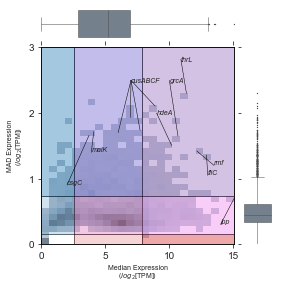

In [29]:
g = plot_expression_stat_2d_hist('median_log_tpm', 'mad_log_tpm',
                             'Median Expression\n($log_{2}$[TPM])', 'MAD Expression\n($log_{2}$[TPM])',
                             (0, 15.06), (0, 3),
                             np.arange(0, 20, 5),
                             np.arange(0, 4, 1),
                             'med_vs_mad',
                            return_g=True)
# g.ax_joint.plot((5, 10), (1,2), linewidth=0.5, color='k')

g.ax_joint.plot((4.091935, 3.9), (1.715796, 1.4), linewidth=0.5, color='k')
g.ax_joint.text(3.9, 1.4, 'malK', ha='left', va='bottom', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((3.718705, 2), (1.660417, 0.9), linewidth=0.5, color='k')
g.ax_joint.text(2, 0.9, 'csgC', ha='left', va='bottom', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((15.061097, 14), (0.69913, 0.3 ), linewidth=0.5, color='k')
g.ax_joint.text(14, 0.3, 'lpp', ha='left', va='bottom', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((12.904223, 13), (1.361117, 1.05), linewidth=0.5, color='k')
g.ax_joint.text(13, 1.05, 'fliC', ha='left', va='bottom', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((12.138267, 13.5), (1.423095, 1.2), linewidth=0.5, color='k')
g.ax_joint.text(13.5, 1.2, 'rmf', ha='left', va='bottom', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((11.336382, 10.9), (2.299772, 2.82), linewidth=0.5, color='k')
g.ax_joint.text(10.9, 2.82, 'thrL', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((10.188254, 9), (1.502302, 2), linewidth=0.5, color='k')
g.ax_joint.text(9, 2, 'hdeA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((10.673675, 10), (1.648417, 2.5), linewidth=0.5, color='k')
g.ax_joint.text(10, 2.5, 'grcA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial')

g.ax_joint.plot((7.709575, 7), (1.738622, 2.5), linewidth=0.5, color='k')
g.ax_joint.plot((8.887357, 7), (2.105144, 2.5), linewidth=0.5, color='k')
g.ax_joint.plot((6.962162, 7), (1.9312, 2.5), linewidth=0.5, color='k')
g.ax_joint.plot((5.992702, 7), (1.699959, 2.5), linewidth=0.5, color='k')
g.ax_joint.text(7, 2.5, 'cusABCF', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial')

# g.ax_joint.plot((10.75, 11.8), (1.575, 1.76), linewidth=0.5, color='k')
# g.ax_joint.text(12, 1.8, 'dps', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial')


# g.ax_joint.plot((2.5, 4.8), (2.7, 2.25), linewidth=0.5, color='k')
# g.ax_joint.plot((2.5, 5.3), (2.7, 2.55), linewidth=0.5, color='k')
# g.ax_joint.text(0.25, 2.8, 'gadABCE', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

tpm_med, tpm_sd = gene_table_pmg['median_log_tpm'].median(), gene_table_pmg['median_log_tpm'].std()
borders_median = tpm_med - tpm_sd, tpm_med + tpm_sd
for border in borders_median:
    g.ax_joint.axvline(border, color='k', linewidth=0.5)
    
mad_med, mad_sd = gene_table_pmg['mad_log_tpm'].median(), gene_table_pmg['mad_log_tpm'].std()
borders_mad = mad_med - mad_sd, mad_med + mad_sd
for border in borders_mad:
    g.ax_joint.axhline(border, color='k', linewidth=0.5)
    
# left middle
g.ax_joint.add_patch(Rectangle((0, borders_mad[0]), borders_median[0], borders_mad[1] - borders_mad[0],alpha=0.2,linewidth=None,color='tab:blue'))
# left top
g.ax_joint.add_patch(Rectangle((0, borders_mad[1]), borders_median[0], 3 - borders_mad[1],alpha=0.4,linewidth=None,color='tab:blue'))
# middle bottom
g.ax_joint.add_patch(Rectangle((borders_median[0], 0), borders_median[1] - borders_median[0], borders_mad[0],alpha=0.2,linewidth=None,color='tab:red'))
# middle middle
g.ax_joint.add_patch(Rectangle((
    borders_median[0], borders_mad[0]), borders_median[1] - borders_median[0], borders_mad[1] - borders_mad[0],alpha=0.4,linewidth=None,
    color='tab:pink'
))
# middle top
g.ax_joint.add_patch(Rectangle((
    borders_median[0], borders_mad[1]), borders_median[1] - borders_median[0], 3 - borders_mad[1],alpha=0.4,linewidth=None,
    color='slateblue'
))
# right bottom
g.ax_joint.add_patch(Rectangle((borders_median[1], 0), 15.06 - borders_mad[1], borders_mad[0],alpha=0.4,linewidth=None,color='tab:red'))
# right middle
g.ax_joint.add_patch(Rectangle((borders_median[1], borders_mad[0]), 15.06 - borders_mad[1], borders_mad[1] - borders_mad[0],alpha=0.4,linewidth=None,
                               color='violet'))
# right top
g.ax_joint.add_patch(Rectangle((borders_median[1], borders_mad[1]), 15.06 - borders_median[1], 3 - borders_mad[1],alpha=0.4,linewidth=None,
                               color='tab:purple'))

# plt.savefig('med_vs_mad.pdf', bbox_inches='tight', dpi=400)
# plt.savefig('C:\\Users\\99hee\\precise_x_k\\investigate_expression\\med_vs_mad.svg'), bbox_inches='tight', dpi=400)

Text(0.8333333333333334, 0.8333333333333334, '119\n(2.8%)')

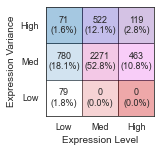

In [30]:
sns.set_style('ticks')

_, ax = plt.subplots(figsize=(2, 2))

ax.set_aspect('equal')

for bord in [1/3, 2/3]:
    ax.axhline(bord, color='k', linewidth=0.5)
    ax.axvline(bord, color='k', linewidth=0.5)
    
ax.set_xticks([1/6, 1/2, 5/6])
ax.set_xticklabels(['Low', 'Med', 'High'])
ax.set_yticks([1/6, 1/2, 5/6])
ax.set_yticklabels(['Low', 'Med', 'High'])
ax.set_xlabel('Expression Level', fontsize=10)
ax.set_ylabel('Expression Variance', fontsize=10)
ax.tick_params(left=False, bottom=False)
ax.tick_params(axis='both', labelsize=9)

ax.add_patch(Rectangle((0, 1/3), 1/3, 1/3,alpha=0.2,linewidth=None,color='tab:blue'))
ax.add_patch(Rectangle((0, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:blue'))
ax.add_patch(Rectangle((1/3, 0), 1/3, 1/3,alpha=0.2,linewidth=None,color='tab:red'))
ax.add_patch(Rectangle((1/3, 1/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:pink'))
ax.add_patch(Rectangle((1/3, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='slateblue'))
ax.add_patch(Rectangle((2/3, 0), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:red'))
ax.add_patch(Rectangle((2/3, 1/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='violet'))
ax.add_patch(Rectangle((2/3, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:purple'))

n_lowlow = gene_table_pmg[(gene_table_pmg['median_log_tpm'] < borders_median[0]) & (gene_table_pmg['mad_log_tpm'] < borders_mad[0])].shape[0]
n_lowmed = gene_table_pmg[(gene_table_pmg['median_log_tpm'] < borders_median[0]) & 
                          ((gene_table_pmg['mad_log_tpm'] >= borders_mad[0]) & (gene_table_pmg['mad_log_tpm'] < borders_mad[1]))].shape[0]
n_lowhigh = gene_table_pmg[(gene_table_pmg['median_log_tpm'] < borders_median[0]) & (gene_table_pmg['mad_log_tpm'] >= borders_mad[1])].shape[0]
n_medlow = gene_table_pmg[((gene_table_pmg['median_log_tpm'] >= borders_median[0]) & (gene_table_pmg['median_log_tpm'] < borders_median[1])) & 
                          (gene_table_pmg['mad_log_tpm'] < borders_mad[0])].shape[0]
n_medmed = gene_table_pmg[((gene_table_pmg['median_log_tpm'] >= borders_median[0]) & (gene_table_pmg['median_log_tpm'] < borders_median[1])) & 
                          ((gene_table_pmg['mad_log_tpm'] >= borders_mad[0]) & (gene_table_pmg['mad_log_tpm'] < borders_mad[1]))].shape[0]
n_medhigh = gene_table_pmg[((gene_table_pmg['median_log_tpm'] >= borders_median[0]) & (gene_table_pmg['median_log_tpm'] < borders_median[1])) & 
                          (gene_table_pmg['mad_log_tpm'] >= borders_mad[1])].shape[0]
n_highlow = gene_table_pmg[(gene_table_pmg['median_log_tpm'] >= borders_median[1]) & (gene_table_pmg['mad_log_tpm'] < borders_mad[0])].shape[0]
n_highmed = gene_table_pmg[(gene_table_pmg['median_log_tpm'] >= borders_median[1]) &
                           ((gene_table_pmg['mad_log_tpm'] >= borders_mad[0]) & (gene_table_pmg['mad_log_tpm'] < borders_mad[1]))].shape[0]
n_highhigh = gene_table_pmg[(gene_table_pmg['median_log_tpm'] >= borders_median[1]) & (gene_table_pmg['mad_log_tpm'] >= borders_mad[1])].shape[0]

ax.text(1/6, 1/6, f'{n_lowlow}\n({n_lowlow/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/6, 1/2, f'{n_lowmed}\n({n_lowmed/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/6, 5/6, f'{n_lowhigh}\n({n_lowhigh/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 1/6, f'{n_medlow}\n({n_medlow/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 1/2, f'{n_medmed}\n({n_medmed/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 5/6, f'{n_medhigh}\n({n_medhigh/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(5/6, 1/6, f'{n_highlow}\n({n_highlow/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(5/6, 1/2, f'{n_highmed}\n({n_highmed/4305*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(5/6, 5/6, f'{n_highhigh}\n({n_highhigh/4305*100:.1f}%)', va='center', ha='center', fontsize=9)

# plt.savefig('med_vs_mad_cat_sum.pdf', bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, f'med_vs_mad_cat_sum.svg'), bbox_inches='tight', dpi=400)

## Inducibility

### Upwards

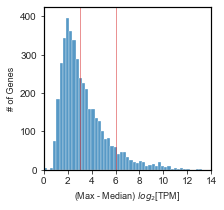

In [31]:
_, ax = plt.subplots(figsize=(3, 3))

sns.histplot(gene_table_pmg['max_to_median'], bins=50, ax=ax)

ax.set_xlabel('(Max - Median) $log_{2}$[TPM]', fontsize=9)
ax.set_ylabel('# of Genes', fontsize=9)

ax.set_ylim(0, 425)
ax.set_xlim(0, 14)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('k')
    s.set_linewidth(1.2)
    
ax.set_xticks(np.arange(0, 16, 2))

borders = [3, 6]
for border in borders:
    ax.axvline(border, color='tab:red', linewidth=0.5)

# plt.savefig(os.path.join(FIG_PATH, 'med_to_max_tpm_categories.png'), bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, 'med_to_max_tpm_categories.svg'), bbox_inches='tight', dpi=400)

### Downwards

Text(-8.5, 400, 'High\n(n=283)')

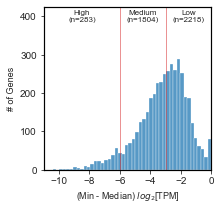

In [32]:
_, ax = plt.subplots(figsize=(3, 3))

sns.histplot(gene_table_pmg['min_to_median'], bins=50, ax=ax)

ax.set_xlabel('(Min - Median) $log_{2}$[TPM]', fontsize=9)
ax.set_ylabel('# of Genes', fontsize=9)

ax.set_ylim(0, 425)
ax.set_xlim(-11, 0)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('k')
    s.set_linewidth(1.2)
    
ax.set_xticks(np.arange(-10, 2, 2))

borders = [-3, -6]
for border in borders:
    ax.axvline(border, color='tab:red', linewidth=0.5)
    
n_low = (gene_table_pmg['min_to_median'] > borders[0]).sum()
n_medium = ((gene_table_pmg['min_to_median'] <= borders[0]) & (gene_table_pmg['min_to_median'] > borders[1])).sum()
n_high = (gene_table_pmg['min_to_median'] <= borders[1]).sum()
    
ax.text(-1.5, 400, f'Low\n(n={n_low})', fontsize=8, va='center', ha='center')
ax.text(-4.5, 400, f'Medium\n(n={n_medium})', fontsize=8, va='center', ha='center')
ax.text(-8.5, 400, f'High\n(n={n_high})', fontsize=8, va='center', ha='center')

# plt.savefig(os.path.join(FIG_PATH, 'med_to_min_tpm_categories.png'), bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, 'med_to_min_tpm_categories.svg'), bbox_inches='tight', dpi=400)

### Upwards/Downwards Inducibility

In [33]:
high_high = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'min_to_median'] < -9:
        if gene_table_pmg.loc[gene, 'max_to_median'] < 3:
            if gene_table_pmg.loc[gene, 'max_to_median'] > 2.5:
                    high_high.append(gene)
            
gene_table_pmg.loc[high_high].sort_values('min_to_median', ascending = True)

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b1074,flgC,U00096.3,NaN,1131438,1131842,+,flagellar basal-body rod protein FlgC,Cell motility,P0ABX2,Op1043,...,False,9.710382,1.324891,12.389803,0.000000,7.606714,-0.680513,12.389803,2.679421,-9.710382
b1073,flgB,U00096.3,NaN,1131018,1131434,+,flagellar basal-body rod protein FlgB,Cell motility,P0ABW9,Op1042,...,False,9.112790,1.486129,11.805873,0.000000,7.259676,-0.697575,11.805873,2.693084,-9.112790
b1923,fliC,U00096.3,NaN,2002110,2003606,-,flagellar filament structural protein,Cell motility,P04949,Op1914,...,False,12.904223,1.361117,15.548967,3.835388,10.921146,-0.663793,11.713579,2.644744,-9.068835
b1886,tar,U00096.3,NaN,1971030,1972691,-,methyl-accepting chemotaxis protein Tar,Cell motility,P07017,Op1879,...,False,9.022505,1.341579,11.647194,0.000000,6.961434,-0.614815,11.647194,2.624689,-9.022505


In [34]:
gene_table_pmg.loc[gene_table_pmg.gene_name == 'tnaA'][['min_to_median', 'max_to_median']]

,min_to_median,max_to_median
b3708,-1.894215,12.723133


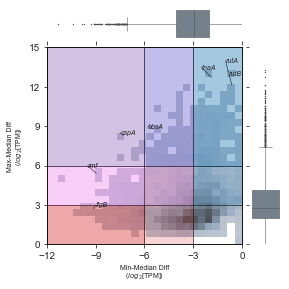

In [35]:
g = plot_expression_stat_2d_hist('min_to_median', 'max_to_median',
                             'Min-Median Diff\n($log_{2}$[TPM])', 'Max-Median Diff\n($log_{2}$[TPM])',
                             (-12, 0), (0, 14),
                             np.arange(-12, 3, 3),
                             np.arange(0, 16, 3),
                             'min_max_median',
                            return_g=True)

# g.ax_joint.plot((-9.710382, -10), (2.679421,2),linewidth=0.5, color='k')
# g.ax_joint.text(-10,2,'flgC', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-9.11279, -9), (2.693084, 3), linewidth=0.5, color='k')
g.ax_joint.text(-9,3,'flgB',ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-8.958707, -9.5), (5.38838, 6), linewidth=0.5, color='k')
g.ax_joint.text(-9.5, 6, 'rmf', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

# g.ax_joint.plot((-8.05409, -8.5), (5.12654, 5.5), linewidth=0.5, color='k')
# g.ax_joint.text(-8.5, 5.5, 'hedA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-7.287638, -7.5), (8.303201, 8.5), linewidth=0.5, color='k')
g.ax_joint.text(-7.5, 8.5, 'cspA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-5.42118, -5.8), (8.779532, 9), linewidth=0.5, color='k')
g.ax_joint.text(-5.8, 9, 'bhsA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

# g.ax_joint.plot((-5.826516, -6), (8.035924, 8.4), linewidth=0.5, color='k')
# g.ax_joint.text(-6, 8.4, 'bssR', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-0.622237, -0.8), (12.138628, 13), linewidth=0.5, color='k')
g.ax_joint.text(-0.8, 13, 'rutB', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-0.836886, -1), (13.115614, 14), linewidth=0.5, color='k')
g.ax_joint.text(-1, 14, 'rutA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.plot((-1.894215, -2.5), (12.723133, 13.5), linewidth=0.5, color='k')
g.ax_joint.text(-2.5, 13.5, 'tnaA', ha='left', va='center', fontsize=7, fontstyle='italic', font='arial', zorder=10)

g.ax_joint.add_patch(Rectangle((-3, 3), 3, 3,alpha=0.2,linewidth=None,color='tab:blue'))
g.ax_joint.add_patch(Rectangle((-3, 6), 3, 9,alpha=0.4,linewidth=None,color='tab:blue'))
g.ax_joint.add_patch(Rectangle((-6, 0), 3, 3,alpha=0.2,linewidth=None,color='tab:red'))
g.ax_joint.add_patch(Rectangle((-6, 3), 3, 3,alpha=0.4,linewidth=None,color='tab:pink'))
g.ax_joint.add_patch(Rectangle((-6, 6), 3, 9,alpha=0.4,linewidth=None,color='slateblue'))
g.ax_joint.add_patch(Rectangle((-12, 0), 6, 3,alpha=0.4,linewidth=None,color='tab:red'))
g.ax_joint.add_patch(Rectangle((-12, 3), 6, 3,alpha=0.4,linewidth=None,color='violet'))
g.ax_joint.add_patch(Rectangle((-12, 6), 6, 9,alpha=0.4,linewidth=None,color='tab:purple'))

borders_min = [-6, -3]
for border in borders_min:
    g.ax_joint.axvline(border, color='k', linewidth=0.5)
    
borders_max = [3, 6]
for border in borders_max:
    g.ax_joint.axhline(border, color='k', linewidth=0.5)

# plt.savefig('min_max_inducibility.pdf', bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, f'min_max_inducibility.svg'), bbox_inches='tight', dpi=400)

Text(0.16666666666666666, 0.8333333333333334, '7\n(0.2%)')

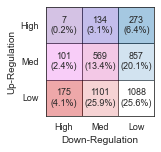

In [36]:
_, ax = plt.subplots(figsize=(2, 2))

ax.set_aspect('equal')

for bord in [1/3, 2/3]:
    ax.axhline(bord, color='k', linewidth=0.5)
    ax.axvline(bord, color='k', linewidth=0.5)
    
ax.set_xticks([1/6, 1/2, 5/6])
ax.set_xticklabels(['High', 'Med', 'Low'])
ax.set_yticks([1/6, 1/2, 5/6])
ax.set_yticklabels(['Low', 'Med', 'High'])
ax.set_xlabel('Down-Regulation', fontsize=10)
ax.set_ylabel('Up-Regulation', fontsize=10)
ax.tick_params(left=False, bottom=False)
ax.tick_params(axis='both', labelsize=9)

ax.add_patch(Rectangle((0, 0), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:red'))
ax.add_patch(Rectangle((0, 1/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='violet'))
ax.add_patch(Rectangle((0, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:purple'))
ax.add_patch(Rectangle((1/3, 0), 1/3, 1/3,alpha=0.2,linewidth=None,color='tab:red'))
ax.add_patch(Rectangle((1/3, 1/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:pink'))
ax.add_patch(Rectangle((1/3, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='slateblue'))
ax.add_patch(Rectangle((2/3, 1/3), 1/3, 1/3,alpha=0.2,linewidth=None,color='tab:blue'))
ax.add_patch(Rectangle((2/3, 2/3), 1/3, 1/3,alpha=0.4,linewidth=None,color='tab:blue'))

n_highlow = gene_table_pmg[(gene_table_pmg['min_to_median'] < borders_min[0]) & (gene_table_pmg['max_to_median'] < borders_max[0])].shape[0]
n_highmed = gene_table_pmg[(gene_table_pmg['min_to_median'] < borders_min[0]) &
                           (gene_table_pmg['max_to_median'] >= borders_max[0]) & (gene_table_pmg['max_to_median'] < borders_max[1])].shape[0]
n_highhigh = gene_table_pmg[(gene_table_pmg['min_to_median'] < borders_min[0]) & (gene_table_pmg['max_to_median'] >= borders_max[1])].shape[0]
n_medlow = gene_table_pmg[(gene_table_pmg['min_to_median'] >= borders_min[0]) & (gene_table_pmg['min_to_median'] < borders_min[1]) & 
                          (gene_table_pmg['max_to_median'] < borders_max[0])].shape[0]
n_medmed = gene_table_pmg[(gene_table_pmg['min_to_median'] >= borders_min[0]) & (gene_table_pmg['min_to_median'] < borders_min[1]) & 
                          (gene_table_pmg['max_to_median'] >= borders_max[0]) & (gene_table_pmg['max_to_median'] < borders_max[1])].shape[0]
n_medhigh = gene_table_pmg[(gene_table_pmg['min_to_median'] >= borders_min[0]) & (gene_table_pmg['min_to_median'] < borders_min[1]) & 
                          (gene_table_pmg['max_to_median'] >= borders_max[1])].shape[0]
n_lowlow = gene_table_pmg[(gene_table_pmg['min_to_median'] > borders_min[1]) & (gene_table_pmg['max_to_median'] < borders_max[0])].shape[0]
n_lowmed = gene_table_pmg[(gene_table_pmg['min_to_median'] > borders_min[1]) &
                          (gene_table_pmg['max_to_median'] >= borders_max[0]) & (gene_table_pmg['max_to_median'] < borders_max[1])].shape[0]
n_lowhigh = gene_table_pmg[(gene_table_pmg['min_to_median'] > borders_min[1]) & (gene_table_pmg['max_to_median'] >= borders_max[1])].shape[0]

ax.text(5/6, 1/6, f'{n_lowlow}\n({n_lowlow/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(5/6, 1/2, f'{n_lowmed}\n({n_lowmed/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(5/6, 5/6, f'{n_lowhigh}\n({n_lowhigh/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 1/6, f'{n_medlow}\n({n_medlow/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 1/2, f'{n_medmed}\n({n_medmed/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/2, 5/6, f'{n_medhigh}\n({n_medhigh/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/6, 1/6, f'{n_highlow}\n({n_highlow/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/6, 1/2, f'{n_highmed}\n({n_highmed/4257*100:.1f}%)', va='center', ha='center', fontsize=9)
ax.text(1/6, 5/6, f'{n_highhigh}\n({n_highhigh/4257*100:.1f}%)', va='center', ha='center', fontsize=9)

# plt.savefig('C:\\Users\\99hee\\precise_x_k\\5_characterize_imodulons\\Figures\\Figure_1\\min_max_med_cat_sum.pdf', bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, f'min_max_med_cat_sum.svg'), bbox_inches='tight', dpi=400)

## Adding Median/MAD/Inducibility Columns [One-Time]

## iModulon Membership

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1760: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  f.tight_layout()
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1760: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  f.tight_layout()


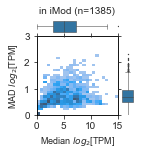

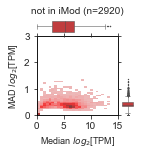

In [37]:
plot_expression_by_boolean_category('in_iM', 'im_membership', 'in iMod')
# plt.savefig('not_in_iM_exp.pdf', bbox_inches='tight', dpi=400)

## y-ome

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1760: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  f.tight_layout()
C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1760: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  f.tight_layout()


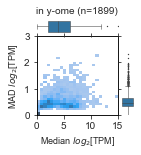

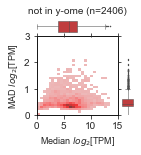

In [38]:
plot_expression_by_boolean_category('y_ome', 'y_ome', 'in y-ome')
# plt.savefig('not_in_yome_exp.pdf', bbox_inches='tight', dpi=400)

### y-ome Fraction in iModulon

In [39]:
gene_table_pmg.loc[gene_table_pmg['in_iM'] == 'True'].y_ome.value_counts()

False    827
True     558
Name: y_ome, dtype: int64

In [40]:
y_genes_in_iM = gene_table_pmg.loc[gene_table_pmg['in_iM'] == 'True'].y_ome.value_counts()[True]
y_genes_not_in_iM = gene_table_pmg.loc[gene_table_pmg['in_iM'] == 'True'].y_ome.value_counts()[False]

y_genes_in_iM*100/(y_genes_in_iM + y_genes_not_in_iM)

40.288808664259925

### by COG category

In [41]:
gene_table_pmg['COG'].value_counts()

Function unknown                                                     823
Transcription                                                        372
Inorganic ion transport and metabolism                               308
Amino acid transport and metabolism                                  303
Energy production and conversion                                     291
No COG annotation                                                    264
Cell wall/membrane/envelope biogenesis                               259
Nucleotide transport and metabolism                                  242
Translation, ribosomal structure and biogenesis                      242
Carbohydrate transport and metabolism                                231
Replication, recombination and repair                                217
Post-translational modification, protein turnover, and chaperones    124
Coenzyme transport and metabolism                                    121
Cell motility                                      

## COG

In [42]:
np.unique(pmg.gene_table.COG.values)

array(['Amino acid transport and metabolism',
       'Carbohydrate transport and metabolism',
       'Cell cycle control, cell division, chromosome partitioning',
       'Cell motility', 'Cell wall/membrane/envelope biogenesis',
       'Coenzyme transport and metabolism', 'Defense mechanisms',
       'Energy production and conversion', 'Function unknown',
       'Inorganic ion transport and metabolism',
       'Intracellular trafficking, secretion, and vesicular transport',
       'Lipid transport and metabolism', 'No COG annotation',
       'Nucleotide transport and metabolism',
       'Post-translational modification, protein turnover, and chaperones',
       'RNA processing and modification',
       'Replication, recombination and repair',
       'Secondary metabolites biosynthesis, transport, and catabolism',
       'Signal transduction mechanisms', 'Transcription',
       'Translation, ribosomal structure and biogenesis'], dtype=object)

In [43]:
cog_short_lookup = {
    'Translation, ribosomal structure and biogenesis': 'Translation',
    'Cell cycle control, cell division, chromosome partitioning': 'Cell cycle',
    'Nucleotide transport and metabolism': 'Nucleotide metabolism',
    'Post-translational modification, protein turnover, and chaperones': 'Post-translational modification',
    'Coenzyme transport and metabolism': 'Coenzyme metabolism',
    'Cell wall/membrane/envelope biogenesis': 'Cell wall/membrane/envelope biogenesis',
    'Amino acid transport and metabolism': 'Amino acid metabolism',
    'Secondary metabolites biosynthesis, transport, and catabolism': 'Secondary metabolites',
    'Transcription': 'Transcription',
    'Function unknown': 'Unknown',
    'Replication, recombination and repair': 'Replication, recombination, and repair',
    'RNA processing and modification': 'RNA processing',
    'Lipid transport and metabolism': 'Lipid metabolism',
    'Signal transduction mechanisms': 'Signal transduction',
    'Defense mechanisms': 'Defense mechanisms',
    'Intracellular trafficking, secretion, and vesicular transport': 'Intracellular trafficking and secretion',
    'Inorganic ion transport and metabolism': 'Inorganic ion metabolism',
    'Energy production and conversion': 'Energy production',
    'Carbohydrate transport and metabolism': 'Carbohydrate metabolism',
    'No COG annotation': 'No COG annotation',
    'Cell motility': 'Cell motility'
}

C:\Users\99hee\AppData\Local\Temp\ipykernel_37768\103858.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order=gene_table_pmg.groupby('COG').median().sort_values('median_log_tpm', ascending=False).index,


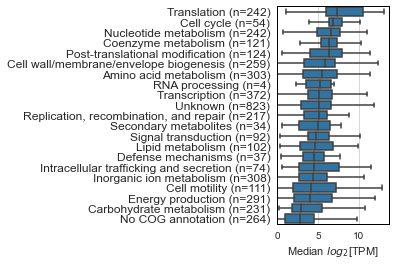

In [44]:
sns.set_style('whitegrid')
_, ax = plt.subplots(figsize=(2, 4))
sns.boxplot(y='COG', x='median_log_tpm', data=gene_table_pmg,
            order=gene_table_pmg.groupby('COG').median().sort_values('median_log_tpm', ascending=False).index,
            orient='h', showfliers=False, color='tab:blue',
           ax=ax)

ax.set_xlabel('Median $log_{2}$[TPM]', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, ax.get_xlim()[1])
old_labs = [t.get_text() for t in ax.get_yticklabels()]
new_labs = [
    f"{cog_short_lookup[cog]} (n={gene_table_pmg[gene_table_pmg['COG'] == cog].shape[0]})"
    for cog in old_labs
]

# new_labs = []

# for cog in old_labs:
#     new_labs.append(str(cog_short_lookup[cog]) + "(n = " + str(gene_table_pmg[gene_table_pmg['COG'] == cog].shape[0]) + ")")
    
    
    
ax.set_yticklabels(new_labs)
ax.tick_params(axis='y', labelsize=12)

for s in ax.spines.values():
    s.set_linewidth(1)
    s.set_color('k')
    
# plt.savefig('expression_by_COG.pdf', bbox_inches='tight', dpi=400)
# plt.savefig(os.path.join(FIG_PATH, 'by_cog.svg'), bbox_inches='tight', dpi=400)

In [45]:
# high m exp, medium mad
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] > 14:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] < 1:
            print(gene_table_pmg.loc[gene])

gene_name                                            lpp
accession                                       U00096.3
old_locus_tag                                        NaN
start                                            1757421
end                                              1757657
strand                                                 +
gene_product                          murein lipoprotein
COG               Cell wall/membrane/envelope biogenesis
uniprot                                           P69776
operon                                            Op1665
regulator             MicL-MicS,OmpR,YfeC,YidZ,YedW,MicL
in_iM                                               True
y_ome                                               True
median_log_tpm                                 15.061097
mad_log_tpm                                      0.69913
max_log_tpm                                    17.656584
min_log_tpm                                     9.913032
mean_log_tpm                   

In [46]:
# high m exp, medium mad
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] > 11:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 2.1:
            print(gene_table_pmg.loc[gene])

gene_name                              thrL
accession                          U00096.3
old_locus_tag                           NaN
start                                   190
end                                     255
strand                                    +
gene_product      thr operon leader peptide
COG                       No COG annotation
uniprot                              P0AD86
operon                                  Op0
regulator               Lrp,RpoD,ppGpp,DksA
in_iM                                  True
y_ome                                  True
median_log_tpm                    11.336382
mad_log_tpm                        2.299772
max_log_tpm                       16.603621
min_log_tpm                             0.0
mean_log_tpm                      10.993618
skew                              -0.485891
range_log_tpm                     16.603621
max_to_median                      5.267239
min_to_median                    -11.336382
Name: b0001, dtype: object


In [47]:
# high m exp, medium mad
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] > 12:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 1:
            print(gene_table_pmg.loc[gene])

gene_name                                                       rmf
accession                                                  U00096.3
old_locus_tag                                                   NaN
start                                                       1015715
end                                                         1015882
strand                                                            +
gene_product                             ribosome modulation factor
COG                 Translation, ribosomal structure and biogenesis
uniprot                                                      P0AFW2
operon                                                        Op925
regulator         Crp,RcdA,McbR,Fur,ZntR,NhaR,ZraR,SdiA,SlyA,Kdp...
in_iM                                                          True
y_ome                                                         False
median_log_tpm                                            12.138267
mad_log_tpm                                     

In [48]:
# high m exp, medium mad
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 7:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 1.7:
            print(gene_table_pmg.loc[gene])

gene_name                      yadX
accession                  U00096.3
old_locus_tag                   NaN
start                        175048
end                          175095
strand                            +
gene_product           protein YadX
COG               No COG annotation
uniprot                      P0DSE3
operon                        Op154
regulator                       NaN
in_iM                          True
y_ome                          True
median_log_tpm             1.868127
mad_log_tpm                1.868127
max_log_tpm                 7.11022
min_log_tpm                     0.0
mean_log_tpm               1.910054
skew                       0.414402
range_log_tpm               7.11022
max_to_median              5.242093
min_to_median             -1.868127
Name: b4765, dtype: object
gene_name                                                      cusB
accession                                                  U00096.3
old_locus_tag                                

In [49]:
# checking what genes are in each category

In [50]:
tpm_med, tpm_sd = gene_table_pmg['median_log_tpm'].median(), gene_table_pmg['median_log_tpm'].std()
borders_median = tpm_med - tpm_sd, tpm_med + tpm_sd

In [51]:
tpm_sd

2.6761985517715314

In [52]:
borders_median

(2.5245174947284688, 7.876914598271531)

In [53]:
mad_med, mad_sd = gene_table_pmg['mad_log_tpm'].median(), gene_table_pmg['mad_log_tpm'].std()
borders_mad = mad_med - mad_sd, mad_med + mad_sd

In [54]:
borders_mad

(0.15352305982478776, 0.7283973191752117)

In [55]:
low_low = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 2.526119100657561:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] < 0.15261879716072568:
            low_low.append(gene)
            
# gene_table_pmg.loc[low_low]

# mostly prophage, unknown function, IS elements

In [56]:
low_medium = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 2.526119100657561:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 0.15261879716072568:
            if gene_table_pmg.loc[gene, 'mad_log_tpm'] < 0.7285150658392744:
                low_medium.append(gene)
            
gene_table_pmg.loc[low_medium]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b0012,mbiA,U00096.3,NaN,10830,11315,+,uncharacterized protein MbiA,No COG annotation,P28697,Op11,...,True,0.380325,0.380325,5.242695,0.0,0.488932,2.931091,5.242695,4.862369,-0.380325
b0013,yaaI,U00096.3,NaN,11382,11786,-,DUF2541 domain-containing protein YaaI,Function unknown,P28696,Op12,...,True,1.258626,0.486631,4.079863,0.0,1.289070,0.288155,4.079863,2.821237,-1.258626
b0021,insB1,U00096.3,NaN,19811,20314,-,IS1 family protein InsB,"Replication, recombination and repair",P0CF25,Op20,...,True,2.144479,0.538163,4.290611,0.0,2.189453,0.109883,4.290611,2.146131,-2.144479
b0035,caiE,U00096.3,NaN,34781,35371,-,putative transferase CaiE,Function unknown,P39206,Op34,...,True,2.167085,0.465016,4.993020,0.0,2.134468,0.023197,4.993020,2.825935,-2.167085
b0036,caiD,U00096.3,NaN,35377,36162,-,crotonobetainyl-CoA hydratase,Lipid transport and metabolism,P31551,Op35,...,False,1.440056,0.389312,4.078268,0.0,1.465578,0.680074,4.078268,2.638212,-1.440056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4357,lgoR,U00096.3,NaN,4594937,4595851,-,putative DNA-binding transcriptional regulator...,Transcription,P39399,Op4258,...,True,2.473479,0.699331,6.975345,0.0,2.798117,0.941337,6.975345,4.501866,-2.473479
b4358,lgoD,U00096.3,NaN,4595990,4597012,+,L-galactonate oxidoreductase,Energy production and conversion,P39400,Op4259,...,False,1.943030,0.586549,7.410767,0.0,1.906508,0.883080,7.410767,5.467737,-1.943030
b4365,yjjQ,U00096.3,NaN,4603477,4604202,+,DNA-binding transcriptional repressor YjjQ,Transcription,P0ADD7,Op4266,...,True,0.730560,0.360894,3.493645,0.0,0.832458,1.438819,3.493645,2.763085,-0.730560
b4366,bglJ,U00096.3,NaN,4604160,4604837,+,DNA-binding transcriptional regulator BglJ,Transcription,P39404,Op4267,...,False,1.782568,0.454202,5.243796,0.0,1.811534,0.701493,5.243796,3.461228,-1.782568


In [57]:
low_high = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 2.526119100657561:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 0.7285150658392744:
            low_high.append(gene)
            
gene_table_pmg.loc[low_high]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b4765,yadX,U00096.3,NaN,175048,175095,+,protein YadX,No COG annotation,P0DSE3,Op154,...,True,1.868127,1.868127,7.110220,0.0,1.910054,0.414402,7.110220,5.242093,-1.868127
b4766,argL,U00096.3,NaN,290275,290370,-,putative translational regulatory protein ArgL,No COG annotation,P0DSE4,Op265,...,True,2.185761,0.875344,6.079881,0.0,2.056346,0.014746,6.079881,3.894120,-2.185761
b0286,paoA,U00096.3,NaN,301884,302573,-,aldehyde dehydrogenase%2C Fe-S subunit,Nucleotide transport and metabolism,P77165,Op280,...,False,2.059751,0.800626,6.720572,0.0,2.342437,0.705493,6.720572,4.660820,-2.059751
b4671,ykgR,U00096.3,NaN,313141,313242,-,putative membrane protein YkgR,No COG annotation,C1P5Z8,Op292,...,True,0.933560,0.933560,7.636073,0.0,1.280285,1.310530,7.636073,6.702513,-0.933560
b0330,prpR,U00096.3,NaN,346857,348443,-,DNA-binding transcriptional dual regulator PrpR,Transcription,P77743,Op323,...,False,2.210009,0.919976,7.368538,0.0,2.308478,0.663427,7.368538,5.158529,-2.210009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4559,ghoT,U00096.3,NaN,4352908,4353081,+,toxin of the GhoTS toxin-antitoxin system,Function unknown,P64646,Op4037,...,True,1.878600,0.894816,7.475225,0.0,2.040582,0.604122,7.475225,5.596625,-1.878600
b4822,ytgB,U00096.3,NaN,4486043,4486099,+,protein YtgB,No COG annotation,P0DV21,Op4164,...,True,1.536803,1.536803,5.964170,0.0,1.640911,0.525736,5.964170,4.427366,-1.536803
b4801,ykiE,U00096.3,NaN,4518372,4518440,+,protein YkiE,No COG annotation,P0DSH9,Op4191,...,True,1.469467,1.469467,6.717943,0.0,1.719053,0.633044,6.717943,5.248476,-1.469467
b4720,ytiC,U00096.3,NaN,4556574,4556675,+,protein YtiC,No COG annotation,P0DPC4,Op4226,...,True,1.962004,1.514587,13.251763,0.0,2.253709,1.497830,13.251763,11.289758,-1.962004


In [58]:
gene_table_pmg.loc[low_high][:50]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b4765,yadX,U00096.3,NaN,175048,175095,+,protein YadX,No COG annotation,P0DSE3,Op154,...,True,1.868127,1.868127,7.110220,0.000000,1.910054,0.414402,7.110220,5.242093,-1.868127
b4766,argL,U00096.3,NaN,290275,290370,-,putative translational regulatory protein ArgL,No COG annotation,P0DSE4,Op265,...,True,2.185761,0.875344,6.079881,0.000000,2.056346,0.014746,6.079881,3.894120,-2.185761
b0286,paoA,U00096.3,NaN,301884,302573,-,aldehyde dehydrogenase%2C Fe-S subunit,Nucleotide transport and metabolism,P77165,Op280,...,False,2.059751,0.800626,6.720572,0.000000,2.342437,0.705493,6.720572,4.660820,-2.059751
b4671,ykgR,U00096.3,NaN,313141,313242,-,putative membrane protein YkgR,No COG annotation,C1P5Z8,Op292,...,True,0.933560,0.933560,7.636073,0.000000,1.280285,1.310530,7.636073,6.702513,-0.933560
b0330,prpR,U00096.3,NaN,346857,348443,-,DNA-binding transcriptional dual regulator PrpR,Transcription,P77743,Op323,...,False,2.210009,0.919976,7.368538,0.000000,2.308478,0.663427,7.368538,5.158529,-2.210009
b4767,ytiB,U00096.3,NaN,391592,391648,-,protein YtiB,No COG annotation,P0DSE5,Op363,...,True,1.281860,1.281860,6.171528,0.000000,1.438661,0.657761,6.171528,4.889668,-1.281860
b0379,yaiY,U00096.3,NaN,399025,399333,-,DUF2755 domain-containing inner membrane prote...,Function unknown,P0AAP7,Op370,...,True,2.342691,0.742988,9.540752,0.000000,2.680716,1.451075,9.540752,7.198061,-2.342691
b0450,glnK,U00096.3,NaN,472598,472936,+,nitrogen regulatory protein PII-2,Transcription,P0AC55,Op440,...,True,2.144688,1.132772,15.394270,0.000000,3.482676,1.710411,15.394270,13.249583,-2.144688
b4588,ylcH,U00096.3,NaN,572368,572469,+,uncharacterized protein YlcH,No COG annotation,Q47268,Op530,...,True,1.268041,1.268041,6.969041,0.000000,1.422600,0.616569,6.969041,5.701000,-1.268041
b4509,ylcG,U00096.3,NaN,573730,573870,+,uncharacterized protein YlcG,No COG annotation,Q47272,Op535,...,True,1.052109,0.916993,5.804381,0.000000,1.238305,0.977166,5.804381,4.752272,-1.052109


In [59]:
high_medium = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] > 7.8788780363424396:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 0.15261879716072568:
            if gene_table_pmg.loc[gene, 'mad_log_tpm'] < 0.7285150658392744:
                high_medium.append(gene)
            
gene_table_pmg.loc[high_medium].sort_values('median_log_tpm', ascending = False)[:50]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b1677,lpp,U00096.3,NaN,1757421,1757657,+,murein lipoprotein,Cell wall/membrane/envelope biogenesis,P69776,Op1665,...,True,15.061097,0.699130,17.656584,9.913032,14.932160,-1.072630,7.743552,2.595487,-5.148064
b1094,acpP,U00096.3,NaN,1151615,1151851,+,acyl carrier protein,Lipid transport and metabolism,P0A6A8,Op1063,...,False,13.599752,0.501767,16.724268,9.011940,13.568053,0.013770,7.712328,3.124516,-4.587812
b0929,ompF,U00096.3,NaN,985894,986982,-,outer membrane porin F,Cell wall/membrane/envelope biogenesis,P02931,Op901,...,False,13.525043,0.654902,15.927381,3.110249,12.921437,-1.837576,12.817132,2.402338,-10.414794
b0957,ompA,U00096.3,NaN,1019013,1020053,-,outer membrane protein A,Cell wall/membrane/envelope biogenesis,P0A910,Op929,...,False,13.112786,0.408794,15.015856,10.185525,13.026582,-0.630615,4.830330,1.903070,-2.927260
b3339,tufA,U00096.3,NaN,3470145,3471329,-,translation elongation factor Tu 1,"Translation, ribosomal structure and biogenesis",P0CE47,Op3265,...,True,13.041205,0.341651,14.029046,8.484284,12.864360,-1.977522,5.544762,0.987841,-4.556921
b3309,rplX,U00096.3,NaN,3447453,3447767,-,50S ribosomal subunit protein L24,"Translation, ribosomal structure and biogenesis",P60624,Op3235,...,False,12.848813,0.452478,14.276312,8.178818,12.669243,-1.228281,6.097494,1.427498,-4.669996
b1717,rpmI,U00096.3,NaN,1799802,1799999,-,50S ribosomal subunit protein L35,"Translation, ribosomal structure and biogenesis",P0A7Q1,Op1705,...,False,12.687127,0.375119,14.884994,9.388039,12.568018,-0.614175,5.496955,2.197867,-3.299088
b1718,infC,U00096.3,NaN,1800096,1800638,-,translation initiation factor IF-3,"Translation, ribosomal structure and biogenesis",P0A707,Op1706,...,False,12.582937,0.264607,13.871221,10.683081,12.525254,-0.570802,3.188140,1.288284,-1.899856
b3637,rpmB,U00096.3,NaN,3811438,3811674,-,50S ribosomal subunit protein L28,"Translation, ribosomal structure and biogenesis",P0A7M2,Op3572,...,False,12.431414,0.493560,13.808442,7.455501,12.238655,-1.758063,6.352940,1.377028,-4.975912
b3301,rplO,U00096.3,NaN,3444105,3444539,-,50S ribosomal subunit protein L15,"Translation, ribosomal structure and biogenesis",P02413,Op3227,...,False,12.422661,0.401412,14.306071,8.849301,12.395784,-0.516209,5.456770,1.883410,-3.573360


In [60]:
high_high = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] > 7.8788780363424396:
        if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 0.7285150658392744:
            high_high.append(gene)
            
gene_table_pmg.loc[high_high].sort_values('mad_log_tpm', ascending = False)[:50]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b0001,thrL,U00096.3,NaN,190,255,+,thr operon leader peptide,No COG annotation,P0AD86,Op0,...,True,11.336382,2.299772,16.603621,0.000000,10.993618,-0.485891,16.603621,5.267239,-11.336382
b0573,cusF,U00096.3,NaN,597131,597463,+,copper/silver export system periplasmic bindin...,Function unknown,P77214,Op559,...,False,8.887357,2.105144,12.880251,0.000000,7.317026,-0.547353,12.880251,3.992894,-8.887357
b1937,fliE,U00096.3,NaN,2012700,2013014,-,flagellar protein FliE,Cell motility,P0A8T5,Op1924,...,True,7.928015,1.963505,12.817948,0.000000,6.613975,-0.382628,12.817948,4.889933,-7.928015
b1882,cheY,U00096.3,NaN,1967048,1967437,-,chemotaxis protein CheY,Transcription,P0AE67,Op1875,...,False,8.765629,1.893830,12.414725,0.921322,7.586974,-0.392753,11.493403,3.649096,-7.844307
b3766,ilvL,U00096.3,NaN,3950322,3950420,+,ilvXGMEDA operon leader peptide,No COG annotation,P62522,Op3698,...,True,10.369586,1.849720,15.478264,4.062283,10.153117,-0.228932,11.415981,5.108677,-6.307303
b2579,grcA,U00096.3,NaN,2716066,2716449,-,stress-induced alternate pyruvate formate-lyas...,Function unknown,P68066,Op2555,...,False,10.673675,1.648417,16.444668,5.230797,10.530987,-0.011765,11.213871,5.770993,-5.442878
b1924,fliD,U00096.3,NaN,2003872,2005278,+,flagellar filament capping protein,Cell motility,P24216,Op1915,...,True,7.931389,1.618615,10.734567,0.620342,6.626304,-0.516698,10.114225,2.803178,-7.311047
b3525,pdeH,U00096.3,NaN,3678420,3679187,-,c-di-GMP phosphodiesterase PdeH,Signal transduction mechanisms,P37646,Op3454,...,False,8.592111,1.610270,11.111865,0.000000,6.720271,-0.589129,11.111865,2.519754,-8.592111
b1071,flgM,U00096.3,NaN,1129835,1130128,-,anti-sigma factor for FliA (sigma(28)),Cell motility,P0AEM4,Op1040,...,False,8.527590,1.516908,12.054601,2.373877,7.806051,-0.427249,9.680724,3.527011,-6.153713
b3510,hdeA,U00096.3,NaN,3656408,3656740,-,periplasmic acid stress chaperone HdeA,Cell wall/membrane/envelope biogenesis,P0AES9,Op3439,...,False,10.188254,1.502302,15.324362,2.143733,10.364860,-0.230750,13.180630,5.136108,-8.044522


In [61]:
medium_high = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'median_log_tpm'] < 7.8788780363424396:
        if gene_table_pmg.loc[gene, 'median_log_tpm'] > 2.526119100657561:
            if gene_table_pmg.loc[gene, 'mad_log_tpm'] > 0.7285150658392744:
                medium_high.append(gene)
            
gene_table_pmg.loc[medium_high].sort_values('median_log_tpm', ascending = False)[:50]

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b3990,thiH,U00096.3,NaN,4190735,4191868,-,2-iminoacetate synthase,Coenzyme transport and metabolism,P30140,Op3899,...,False,7.877362,0.738551,10.610868,0.615086,7.194940,-1.328728,9.995782,2.733506,-7.262276
b4411,ecnB,U00096.3,NaN,4376553,4376699,+,bacteriolytic entericidin B lipoprotein,Function unknown,P0ADB7,Op4057,...,True,7.865102,1.351126,13.217436,2.468280,7.921816,0.201271,10.749156,5.352333,-5.396822
b3049,glgS,U00096.3,NaN,3191739,3191939,-,surface composition regulator,Function unknown,P26649,Op2990,...,True,7.837404,1.081853,14.712983,2.072409,7.970702,0.263742,12.640574,6.875579,-5.764995
b4529,ydbJ,U00096.3,NaN,1441058,1441324,+,DUF333 domain-containing protein YdbJ,Function unknown,P0ACW2,Op1361,...,True,7.793163,0.737834,11.364328,4.749016,7.846250,0.157595,6.615312,3.571166,-3.044146
b1194,ycgR,U00096.3,NaN,1243793,1244527,-,flagellar brake protein YcgR,Cell wall/membrane/envelope biogenesis,P76010,Op1165,...,False,7.789764,1.693777,10.437809,0.000000,6.404725,-0.487875,10.437809,2.648045,-7.789764
b2156,lysP,U00096.3,NaN,2247063,2248532,-,lysine:H(+) symporter,Amino acid transport and metabolism,P25737,Op2131,...,False,7.784143,0.979758,10.350700,3.035450,7.404361,-0.692186,7.315250,2.566557,-4.748693
b1248,yciU,U00096.3,NaN,1306821,1307150,-,DUF440 domain-containing protein YciU,Function unknown,P0A8L7,Op1220,...,True,7.777430,0.757308,9.974907,4.787392,7.728397,-0.195385,5.187515,2.197477,-2.990038
b1062,pyrC,U00096.3,NaN,1121561,1122607,-,dihydroorotase,Nucleotide transport and metabolism,P05020,Op1031,...,False,7.744218,0.778594,10.518021,1.569593,7.362126,-1.032639,8.948428,2.773803,-6.174625
b3670,ilvN,U00096.3,NaN,3850802,3851092,-,acetohydroxy acid synthase I subunit IlvN,Amino acid transport and metabolism,P0ADF8,Op3606,...,False,7.725882,0.793741,10.985592,2.400682,7.301018,-0.917197,8.584910,3.259709,-5.325200
b2904,gcvH,U00096.3,NaN,3049160,3049549,-,glycine cleavage system H protein,Amino acid transport and metabolism,P0A6T9,Op2848,...,False,7.724508,0.910655,13.244493,3.631640,7.926947,1.050240,9.612853,5.519984,-4.092869


In [62]:
high_high = []
for gene in gene_table_pmg.index.values:
    if gene_table_pmg.loc[gene, 'min_to_median'] < -9:
        if gene_table_pmg.loc[gene, 'max_to_median'] < 3:
            if gene_table_pmg.loc[gene, 'max_to_median'] > 2.5:
                    high_high.append(gene)
            
gene_table_pmg.loc[high_high].sort_values('min_to_median', ascending = True)

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,...,y_ome,median_log_tpm,mad_log_tpm,max_log_tpm,min_log_tpm,mean_log_tpm,skew,range_log_tpm,max_to_median,min_to_median
b1074,flgC,U00096.3,NaN,1131438,1131842,+,flagellar basal-body rod protein FlgC,Cell motility,P0ABX2,Op1043,...,False,9.710382,1.324891,12.389803,0.000000,7.606714,-0.680513,12.389803,2.679421,-9.710382
b1073,flgB,U00096.3,NaN,1131018,1131434,+,flagellar basal-body rod protein FlgB,Cell motility,P0ABW9,Op1042,...,False,9.112790,1.486129,11.805873,0.000000,7.259676,-0.697575,11.805873,2.693084,-9.112790
b1923,fliC,U00096.3,NaN,2002110,2003606,-,flagellar filament structural protein,Cell motility,P04949,Op1914,...,False,12.904223,1.361117,15.548967,3.835388,10.921146,-0.663793,11.713579,2.644744,-9.068835
b1886,tar,U00096.3,NaN,1971030,1972691,-,methyl-accepting chemotaxis protein Tar,Cell motility,P07017,Op1879,...,False,9.022505,1.341579,11.647194,0.000000,6.961434,-0.614815,11.647194,2.624689,-9.022505
